<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_7/enc_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encontro 7: Relações entre variáveis e correlação

**Instrutor**: Jhonatan Lopes

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [2]:
arxiv_url = (
    "https://raw.githubusercontent.com/jhlopesalves/"
    "eda_humanidades/refs/heads/main/"
    "encontro_5/data/arxiv_eda_papers.csv"
)

arxiv_df = pd.read_csv(
    arxiv_url,
    dtype={"paper_id": "string"},
)

In [3]:
arxiv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   paper_id          3387 non-null   string
 1   title             3387 non-null   object
 2   abstract_preview  3387 non-null   object
 3   primary_category  3387 non-null   object
 4   category_label    3387 non-null   object
 5   top_level         3387 non-null   object
 6   top_level_label   3387 non-null   object
 7   year              3387 non-null   int64 
 8   decade            3387 non-null   object
 9   n_authors         3387 non-null   int64 
 10  n_versions        3387 non-null   int64 
 11  n_categories      3387 non-null   int64 
 12  title_n_words     3387 non-null   int64 
 13  abstract_n_words  3387 non-null   int64 
 14  has_doi           3387 non-null   bool  
 15  has_journal_ref   3387 non-null   bool  
dtypes: bool(2), int64(6), object(7), string(1)
memory usage: 377

In [4]:
arxiv_df.sample(
    n=5,
    random_state=42,
)

,paper_id,title,abstract_preview,primary_category,category_label,top_level,top_level_label,year,decade,n_authors,n_versions,n_categories,title_n_words,abstract_n_words,has_doi,has_journal_ref
238,2108.10682,Hybrid deep learning methods for phenotype pre...,Identifying patient cohorts from clinical note...,cs.CL,Computational Linguistics / NLP,cs,Computer Science,2021,2020s,3,3,2,10,200,True,False
1157,2204.12495,Enhancing Privacy against Inversion Attacks in...,Federated learning reduces the risk of informa...,cs.LG,Machine Learning,cs,Computer Science,2022,2020s,5,1,4,13,196,False,False
2396,2002.02779,Generating Digital Twins with Multiple Scleros...,Multiple Sclerosis (MS) is a neurodegenerative...,stat.ML,Statistical Machine Learning,stat,Statistics,2020,2020s,6,2,3,10,130,False,False
51,2212.03830,A Hierarchical Deep Reinforcement Learning Fra...,Unmanned combat air vehicle (UCAV) combat is a...,cs.AI,Artificial Intelligence,cs,Computer Science,2022,2020s,5,1,3,11,208,False,False
2178,2403.08646,Covariance Fitting Interferometric Phase Linki...,Interferometric phase linking (IPL) has become...,stat.AP,Applied Statistics,stat,Statistics,2024,2020s,5,1,1,10,164,False,False


In [5]:
colunas_numericas = arxiv_df.select_dtypes(include="number")

colunas_numericas.describe().T

,count,mean,std,min,25%,50%,75%,max
year,3387.0,2022.854739,1.732267,2020.0,2021.0,2023.0,2024.0,2025.0
n_authors,3387.0,4.202834,4.305577,1.0,2.0,4.0,5.0,182.0
n_versions,3387.0,1.695010,0.992284,1.0,1.0,1.0,2.0,8.0
n_categories,3387.0,2.184529,1.113424,1.0,1.0,2.0,3.0,8.0
title_n_words,3387.0,9.912902,3.524000,2.0,7.0,10.0,12.0,32.0
abstract_n_words,3387.0,172.085326,47.876997,38.0,139.0,171.0,204.0,310.0


## Relações entre variáveis

Até agora, grande parte de nossa análise exploratória examinou uma variável
por vez: sua distribuição, seu centro, sua dispersão e sua forma.

Também podemos examinar como duas variáveis quantitativas variam em conjunto

### Número de autores e comprimento do abstract


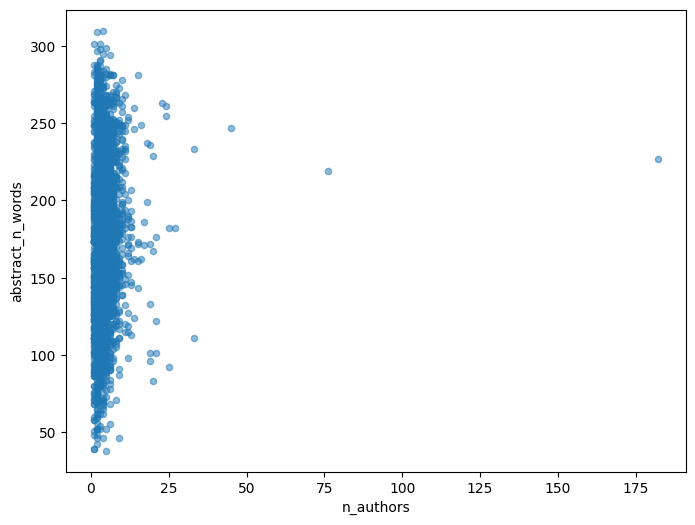

In [6]:
arxiv_df.plot(
    kind="scatter",
    x="n_authors",
    y="abstract_n_words",
    alpha=0.5,
    figsize=(8, 6),
)

plt.show()

### Uma observação extrema

O gráfico contém uma observação com 182 autores, muito distante das demais. Antes de decidir como tratá-la, convém verificar se o valor corresponde a uma observação válida ou a um problema nos dados.

In [7]:
arxiv_df[
    [
        "paper_id",
        "title",
        "n_authors",
        "abstract_n_words",
    ]
].nlargest(
    n=10,
    columns="n_authors",
)

,paper_id,title,n_authors,abstract_n_words
610,2509.01322,LongCat-Flash Technical Report,182,227
493,2409.18486,Evaluation of OpenAI o1: Opportunities and Cha...,76,219
449,2405.19327,MAP-Neo: Highly Capable and Transparent Biling...,45,247
1349,2310.10537,Microscaling Data Formats for Deep Learning,33,111
1655,2508.14948,Large Foundation Model for Ads Recommendation,33,233
343,2305.11938,XTREME-UP: A User-Centric Scarce-Data Benchmar...,27,182
3,2003.03875,Overview of the CCKS 2019 Knowledge Graph Eval...,25,92
1618,2506.05321,LSM-2: Learning from Incomplete Wearable Senso...,25,182
693,2307.03718,Frontier AI Regulation: Managing Emerging Risk...,24,261
935,2512.07846,MixLM: High-Throughput and Effective LLM Ranki...,24,255


### Verificação na fonte

O artigo com 182 autores pode ser consultado diretamente no arXiv.

Uma verificação simples da lista de autores permite conferir se o valor
registrado no conjunto de dados corresponde ao artigo original.

In [8]:
# Seleciona os artigos com equipes excepcionalmente grandes e cria
# uma cópia independente desse subconjunto
large_author = arxiv_df.loc[
    arxiv_df["n_authors"] > 75,
    [
        "paper_id",
        "title",
        "n_authors",
        "title_n_words",
        "abstract_n_words",
        "n_versions",
        "n_categories",
    ]
].copy()

# Constrói um link para a página original de cada artigo no arXiv
large_author["arxiv_url"] = (
    "https://arxiv.org/abs/"
    + large_author["paper_id"]
)

large_author

,paper_id,title,n_authors,title_n_words,abstract_n_words,n_versions,n_categories,arxiv_url
493,2409.18486,Evaluation of OpenAI o1: Opportunities and Cha...,76,9,219,4,1,https://arxiv.org/abs/2409.18486
610,2509.01322,LongCat-Flash Technical Report,182,3,227,2,4,https://arxiv.org/abs/2509.01322


In [9]:
authors_longcat = (
    "Meituan LongCat Team, Bayan, Bei Li, Bingye Lei, Bo Wang, Bolin Rong, Chao Wang, Chao Zhang, Chen Gao, Chen Zhang, Cheng Sun, Chengcheng Han, Chenguang Xi, Chi Zhang, Chong Peng, Chuan Qin, Chuyu Zhang, Cong Chen, Congkui Wang, Dan Ma, Daoru Pan, Defei Bu, Dengchang Zhao, Deyang Kong, Dishan Liu, Feiye Huo, Fengcun Li, Fubao Zhang, Gan Dong, Gang Liu, Gang Xu, Ge Li, Guoqiang Tan, Guoyuan Lin, Haihang Jing, Haomin Fu, Haonan Yan, Haoxing Wen, Haozhe Zhao, Hong Liu, Hongmei Shi, Hongyan Hao, Hongyin Tang, Huantian Lv, Hui Su, Jiacheng Li, Jiahao Liu, Jiahuan Li, Jiajun Yang, Jiaming Wang, Jian Yang, Jianchao Tan, Jiaqi Sun, Jiaqi Zhang, Jiawei Fu, Jiawei Yang, Jiaxi Hu, Jiayu Qin, Jingang Wang, Jiyuan He, Jun Kuang, Junhui Mei, Kai Liang, Ke He, Kefeng Zhang, Keheng Wang, Keqing He, Liang Gao, Liang Shi, Lianhui Ma, Lin Qiu, Lingbin Kong, Lingtong Si, Linkun Lyu, Linsen Guo, Liqi Yang, Lizhi Yan, Mai Xia, Man Gao, Manyuan Zhang, Meng Zhou, Mengxia Shen, Mingxiang Tuo, Mingyang Zhu, Peiguang Li, Peng Pei, Peng Zhao, Pengcheng Jia, Pingwei Sun, Qi Gu, Qianyun Li, Qingyuan Li, Qiong Huang, Qiyuan Duan, Ran Meng, Rongxiang Weng, Ruichen Shao, Rumei Li, Shizhe Wu, Shuai Liang , Shuo Wang, Suogui Dang, Tao Fang, Tao Li, Tefeng Chen, Tianhao Bai, Tianhao Zhou, Tingwen Xie, Wei He, Wei Huang, Wei Liu, Wei Shi, Wei Wang, Wei Wu, Weikang Zhao, Wen Zan, Wenjie Shi, Xi Nan, Xi Su, Xiang Li, Xiang Mei, Xiangyang Ji, Xiangyu Xi, Xiangzhou Huang, Xianpeng Li, Xiao Fu, Xiao Liu, Xiao Wei, Xiaodong Cai, Xiaolong Chen, Xiaoqing Liu, Xiaotong Li, Xiaowei Shi, Xiaoyu Li, Xili Wang, Xin Chen, Xing Hu, Xingyu Miao, Xinyan He, Xuemiao Zhang, Xueyuan Hao, Xuezhi Cao, Xunliang Cai, Xurui Yang, Yan Feng, Yang Bai, Yang Chen, Yang Yang, Yaqi Huo, Yerui Sun, Yifan Lu, Yifan Zhang, Yipeng Zang, Yitao Zhai, Yiyang Li, Yongjing Yin, Yongkang Lv, Yongwei Zhou, Yu Yang, Yuchen Xie, Yueqing Sun, Yuewen Zheng, Yuhuai Wei, Yulei Qian, Yunfan Liang, Yunfang Tai, Yunke Zhao, Zeyang Yu, Zhao Zhang, Zhaohua Yang, Zhenchao Zhang, Zhikang Xia, Zhiye Zou, Zhizhao Zeng, Zhongda Su, Zhuofan Chen, Zijian Zhang, Ziwen Wang, Zixu Jiang, Zizhe Zhao, Zongyu Wang, Zunhai Su"
)

# Cada autor é separado por uma vírgula na lista original.
longcat_authors = authors_longcat.split(",")

len(longcat_authors)

182

A contagem da lista de autores confirma o valor registrado no conjunto de
dados: 182 autores.

Trata-se, portanto, de uma observação extrema, mas válida.

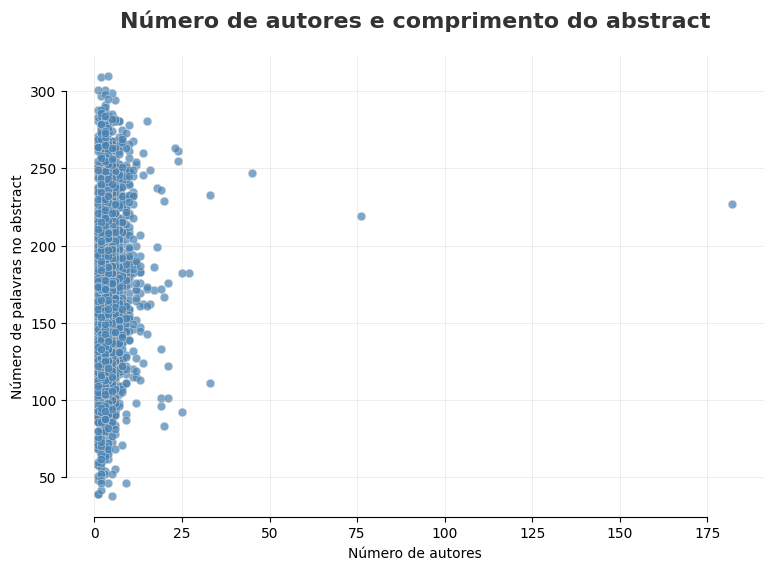

In [10]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

# A transparência ajuda a revelar regiões com sobreposição de pontos
sns.scatterplot(
    data=arxiv_df,
    y="abstract_n_words",
    x="n_authors",
    color="steelblue",
    edgecolor="lightgrey",
    alpha=0.7,
    ax=ax,
)

ax.set_title(
    "Número de autores e comprimento do abstract",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#333333",
)

ax.set(
    xlabel="Número de autores",
    ylabel="Número de palavras no abstract",
)
ax.grid(True, alpha=0.4, linewidth=0.4)

sns.despine(
    ax=ax, trim=True,
)

plt.show()

### Transformação logarítmica

A variável `n_authors` assume apenas valores positivos e varia de 1 a 182.

Em base 10, a transformação logarítmica converte razões multiplicativas em
diferenças aditivas. Multiplicar um valor por 10 acrescenta 1 ao seu logaritmo.

Como o logaritmo é uma função estritamente crescente, a ordenação dos valores
é preservada.

In [11]:
author_counts = np.array(
    [1, 2, 5, 10, 20, 50, 100, 182]
)

log10_author_counts = np.log10(
    author_counts
)

pd.DataFrame(
    {
        "Número de autores": author_counts,
        "log10(n_authors)": log10_author_counts,
        "Restaurado": 10 ** log10_author_counts,
    }
).round(3)

,Número de autores,log10(n_authors),Restaurado
0,1,0.000,1.0
1,2,0.301,2.0
2,5,0.699,5.0
3,10,1.000,10.0
4,20,1.301,20.0
5,50,1.699,50.0
6,100,2.000,100.0
7,182,2.260,182.0


Cada valor positivo possui uma representação correspondente na escala
logarítmica e pode ser recuperado pela transformação inversa.

Por exemplo:

$$
182
\rightarrow
\log_{10}(182)
\rightarrow
10^{\log_{10}(182)}
=
182
$$

A transformação preserva a ordenação dos valores, mas altera as distâncias
entre eles.

### Escala logarítmica no eixo

Transformar os valores e alterar a escala do eixo são operações relacionadas,
mas distintas. Em um eixo logarítmico, `n_authors` permanece armazenada na
escala original; apenas sua posição no eixo é determinada pela transformação
logarítmica.

Em base 10, fatores multiplicativos iguais ocupam distâncias iguais. Assim,
as mudanças de 1 para 10 e de 10 para 100 ocupam a mesma distância no eixo,
pois ambas correspondem a uma multiplicação por 10.

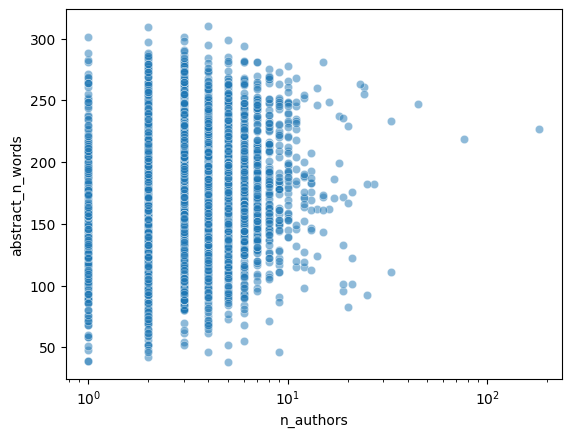

In [12]:
ax = sns.scatterplot(
    data=arxiv_df,
    x="n_authors",
    y="abstract_n_words",
    alpha=0.5,
)

ax.set_xscale(
    "log",
    base=10,
)

plt.show()

Para o gráfico final, os rótulos podem ser mais densos na região das pequenas
contagens e mais espaçados à medida que os valores aumentam.

Na primeira região, uma sequência aritmética é adequada porque queremos
representar individualmente as pequenas contagens. Para os valores maiores,
uma sequência geométrica acompanha melhor a estrutura multiplicativa da escala
logarítmica.

`np.arange()` gera os valores igualmente espaçados na escala original;
`np.geomspace()` gera valores aproximadamente igualmente espaçados na escala
logarítmica.

In [13]:
import matplotlib.ticker as ticker

# Rótulos densos na região em que se concentram as pequenas contagens.
dense_ticks = np.arange(
    start=1,
    stop=9,
)

# Rótulos geometricamente espaçados para a região das contagens maiores.
geometric_ticks = np.geomspace(
    start=10,
    stop=arxiv_df["n_authors"].max(),
    num=6,
)

# Os valores gerados por geomspace são contínuos; arredondamos para
# contagens inteiras antes de combinar as duas sequências.
geometric_ticks = np.rint(
    geometric_ticks
).astype(int)

# Combina as duas regiões e remove eventuais valores repetidos.
x_ticks = np.unique(
    np.concatenate(
        [
            dense_ticks,
            geometric_ticks,
        ]
    )
)

x_ticks

array([  1,   2,   3,   4,   5,   6,   7,   8,  10,  18,  32,  57, 102,
       182])

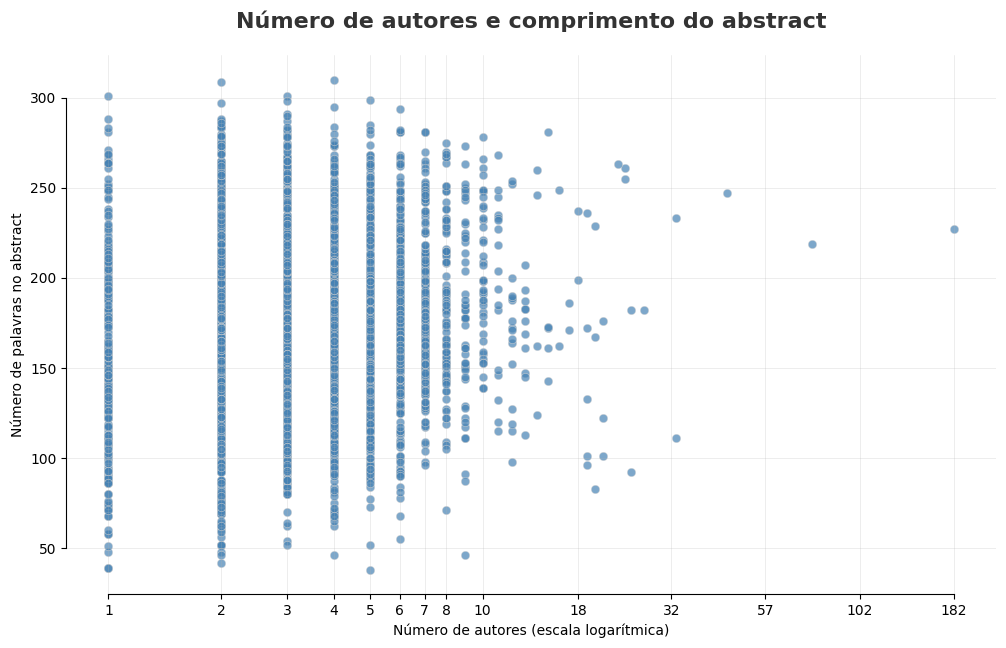

In [14]:
fig, ax = plt.subplots(
    figsize=(12, 7)
)

sns.scatterplot(
    data=arxiv_df,
    x="n_authors",
    y="abstract_n_words",
    color="steelblue",
    edgecolor="lightgrey",
    alpha=0.7,
    ax=ax,
)

ax.set_title(
    "Número de autores e comprimento do abstract",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#333333",
)

ax.set(
    xlabel="Número de autores (escala logarítmica)",
    ylabel="Número de palavras no abstract",
)

ax.grid(
    True,
    alpha=0.4,
    linewidth=0.4,
)

# Mantém os valores originais, mas altera sua posição no eixo.
ax.set_xscale("log")

# Escolhe explicitamente quais valores serão mostrados no eixo.
ax.set_xticks(
    x_ticks
)

# Exibe 1, 10, 100 etc. como números comuns, e não como potências de 10.
ax.xaxis.set_major_formatter(
    ticker.ScalarFormatter()
)

# Remove subdivisões automáticas do eixo logarítmico que não serão rotuladas.
ax.xaxis.set_minor_locator(
    ticker.NullLocator()
)

sns.despine(
    ax=ax,
    trim=True,
)

plt.show()

Os dois gráficos representam exatamente os mesmos artigos e os mesmos valores de n_authors e abstract_n_words, incluindo o artigo com 182 autores.

Na escala linear, diferenças aditivas iguais ocupam distâncias iguais. Por
exemplo, a distância entre 10 e 20 é a mesma que entre 20 e 30.

Na escala logarítmica, razões iguais ocupam distâncias iguais. Por exemplo, a
distância entre 1 e 10 é a mesma que entre 10 e 100, pois ambas representam uma
multiplicação por 10.

Por isso, a escala logarítmica permite examinar com mais detalhe a região onde
se concentra a maior parte dos artigos sem remover as observações mais extremas.